# Gaussian process flow modeling: a narrated walkthrough

This notebook is the guided entry point to the project. We build a synthetic,
divergence-free velocity field, reconstruct it from a handful of noisy
measurements with a Gaussian process, read off the posterior uncertainty as a
map, and finally advect particles through the flow with a Runge-Kutta
integrator. Every step is fully offline and reproducible from a fixed seed.

The companion `docs/method.md` carries the full derivations. Here we keep the
prose tight and let the figures and printed numbers do the talking.

## 1. A field that cannot leak

We want an incompressible flow, one where `du/dx + dv/dy = 0` everywhere. Rather
than enforce that after the fact, we build it in. Define the velocity as the curl
of a scalar stream function `psi`:

    u =  d psi / d y
    v = -d psi / d x

Then `du/dx + dv/dy = d^2 psi/(dx dy) - d^2 psi/(dy dx) = 0` because mixed
partials commute. The field is divergence free by construction. We use a sum of
sinusoidal modes for `psi`, whose curl has a closed form, so we can sample the
velocity analytically at any point.

In [1]:
import numpy as np
from flowgp import synthetic_flow_field, divergence

field = synthetic_flow_field(n=45, seed=0)

# The numerical divergence is not exactly zero, but it is tiny compared to the
# size of the velocity gradients it is built from, and it shrinks as the grid is
# refined (see the test suite). It is finite-difference error, not a real source.
dx = field.xs[1] - field.xs[0]
interior = divergence(field)[2:-2, 2:-2]
gradient_scale = np.abs(np.gradient(field.u, dx, axis=1)).mean()
print(f"mean |divergence| (interior): {np.abs(interior).mean():.3e}")
print(f"as a fraction of gradient magnitude: {np.abs(interior).mean() / gradient_scale:.2%}")

mean |divergence| (interior): 1.456e-02
as a fraction of gradient magnitude: 0.47%


## 2. Sparse noisy observations

A real survey never measures the whole field. It samples it at scattered points,
with instrument noise. We draw a few hundred such measurements and hold out a
third to test the reconstruction honestly.

In [2]:
from flowgp import make_observations, train_test_split_points

points, vel = make_observations(field, n_obs=200, noise=0.05, seed=0)
p_tr, v_tr, p_te, v_te = train_test_split_points(points, vel, seed=0)
print(f"{len(points)} observations: {len(p_tr)} train, {len(p_te)} test")

200 observations: 140 train, 60 test


## 3. The Gaussian process and its kernel

A Gaussian process puts a prior over functions and conditions it on the data. The
prior is set entirely by the kernel, the covariance between function values at
two points. We use a radial basis function plus a white-noise term:

    k(p, q) = sigma_f^2 * exp(-||p - q||^2 / (2 l^2)) + sigma_n^2 * delta(p, q)

The RBF part says nearby points move together, with correlation decaying over a
length scale `l`. The white-noise part accounts for measurement noise. The
hyperparameters are fit by maximizing the log marginal likelihood. We model the
two velocity components with independent GPs.

The posterior at a test point is Gaussian with

    mean     = k_*^T K^{-1} y
    variance = k_** - k_*^T K^{-1} k_*

Note that the variance depends only on *where* the observations are, not on their
values. It is small near data and grows into the gaps. That is the map we plot in
the next section.

In [3]:
from flowgp import GPFieldModel
from flowgp.field import sample_velocity
from flowgp import rmse, nlpd, coverage

gp = GPFieldModel(length_scale=1.0, seed=0).fit(p_tr, v_tr)

true_te = sample_velocity(field, p_te)          # noise-free ground truth
mean_te, std_te = gp.predict(p_te, return_std=True)

print(f"held-out RMSE vs ground truth : {rmse(mean_te, true_te):.4f}")
print(f"held-out mean NLPD            : {nlpd(mean_te, std_te, true_te):.4f}")
print(f"1-sigma coverage (nominal .68): {coverage(mean_te, std_te, true_te, 1.0):.3f}")
print(f"2-sigma coverage (nominal .95): {coverage(mean_te, std_te, true_te, 2.0):.3f}")
print(f"log marginal likelihood (u+v): {gp.log_marginal_likelihood():.2f}")
print('fitted u-kernel:', gp.kernel_[0])

held-out RMSE vs ground truth : 0.2319
held-out mean NLPD            : -1.2079
1-sigma coverage (nominal .68): 0.825
2-sigma coverage (nominal .95): 1.000
log marginal likelihood (u+v): 101.20
fitted u-kernel: 2.4**2 * RBF(length_scale=0.988) + WhiteKernel(noise_level=0.000814)


## 4. The hero: an uncertainty map over the reconstructed flow

We predict the full field on a grid, take the posterior standard deviation as an
uncertainty map, and overlay the reconstructed streamlines and the observation
sites. The dark low-uncertainty regions hug the data; the bright band along the
sparse edge is where the reconstruction openly admits it is guessing.

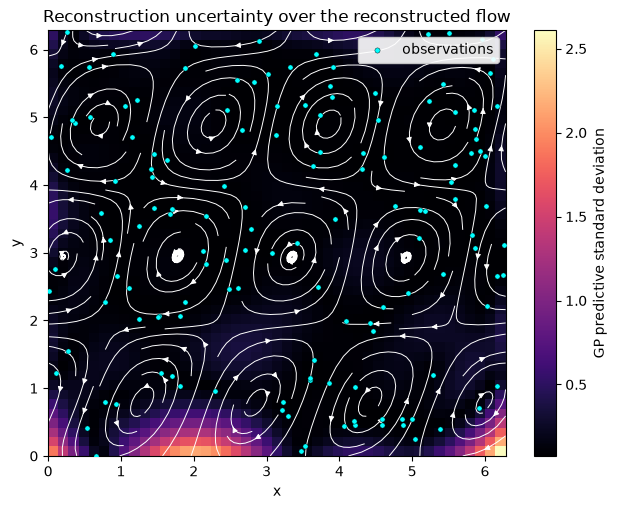

In [4]:
import matplotlib.pyplot as plt

gx, gy = np.meshgrid(field.xs, field.ys)
grid = np.column_stack([gx.ravel(), gy.ravel()])
mean, std = gp.predict(grid, return_std=True)
u_rec = mean[:, 0].reshape(field.u.shape)
v_rec = mean[:, 1].reshape(field.v.shape)
std_mag = np.hypot(std[:, 0], std[:, 1]).reshape(field.u.shape)

fig, ax = plt.subplots(figsize=(6.4, 5.2))
im = ax.imshow(std_mag, origin='lower', extent=field.extent, cmap='magma', aspect='auto')
ax.streamplot(gx, gy, u_rec, v_rec, color='white', density=1.1, linewidth=0.7, arrowsize=0.8)
ax.scatter(p_tr[:, 0], p_tr[:, 1], s=14, c='cyan', edgecolors='black', linewidths=0.3,
           label='observations', zorder=3)
ax.set(xlim=field.extent[:2], ylim=field.extent[2:], xlabel='x', ylabel='y',
       title='Reconstruction uncertainty over the reconstructed flow')
fig.colorbar(im, ax=ax, label='GP predictive standard deviation')
ax.legend(loc='upper right', framealpha=0.9)
plt.tight_layout(); plt.show()

## 5. Advecting particles through the flow

A passive particle obeys `dp/dt = V(p)`. We integrate it with the classical
fourth-order Runge-Kutta step, which evaluates the velocity four times per step
and combines them:

    k1 = V(p)
    k2 = V(p + dt/2 k1)
    k3 = V(p + dt/2 k2)
    k4 = V(p + dt   k3)
    p_next = p + dt/6 (k1 + 2 k2 + 2 k3 + k4)

Its global error is O(dt^4), which keeps trajectories faithful even after a
particle circulates many times through a vortex. We release a line of particles
and trace them through the true field.

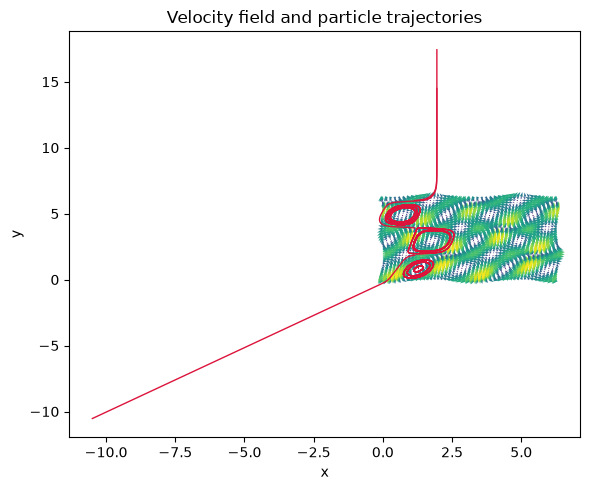

In [5]:
from flowgp import advect_particles

starts = np.column_stack([np.full(12, field.xs[8]), np.linspace(field.ys[2], field.ys[-3], 12)])
traj = advect_particles(field, starts, n_steps=200, dt=0.03)

plt.figure(figsize=(6, 5))
plt.quiver(gx, gy, field.u, field.v, np.hypot(field.u, field.v), cmap='viridis')
for p in range(traj.shape[1]):
    plt.plot(traj[:, p, 0], traj[:, p, 1], color='crimson', linewidth=1)
plt.title('Velocity field and particle trajectories')
plt.xlabel('x'); plt.ylabel('y'); plt.tight_layout(); plt.show()

## Where to go next

- Swap the true field for the GP posterior mean as the velocity function and
  advect through the *reconstructed* field, then compare trajectories.
- Run `python examples/reconstruct_from_sample.py` for the same pipeline on the
  committed CSV sample, with no field regeneration.
- Read `docs/method.md` for the full derivations behind every step here.